In [10]:
pip install pandas geopandas shapely matplotlib requests

Note: you may need to restart the kernel to use updated packages.


In [11]:
# 1. PREPARACIÓN DEL ENTORNO

import pandas as pds
import matplotlib.pyplot as plt

print("Todo funciona correctamente")

Todo funciona correctamente


In [12]:
# 2. CARGA DE LOS DATOS 
# Cargar archivo CSV de centros de salud    
csv_file = "../Data/centros_salud_Madrid.csv"

df = pds.read_csv(
    csv_file,
    sep=";",
    encoding="cp1252"
)

print("Archivo cargado correctamente")
display(df.head())



Archivo cargado correctamente


,PK,NOMBRE,DESCRIPCION-ENTIDAD,HORARIO,EQUIPAMIENTO,TRANSPORTE,DESCRIPCION,ACCESIBILIDAD,CONTENT-URL,NOMBRE-VIA,...,COD-DISTRITO,DISTRITO,COORDENADA-X,COORDENADA-Y,LATITUD,LONGITUD,TELEFONO,FAX,EMAIL,TIPO
0,5855213,Centro Concertado de adicciones (CCAD) Centro ...,El Centro concertado de adicciones Centro form...,De lunes a viernes de 9 a 17 horas,Valoración interdisciplinar del/de la paciente...,"Metro: Alonso Martínez, L4, L5, L10",Forma de acceso: directo,1,http://www.madrid.es/sites/v/index.jsp?vgnextc...,HERMANOS ALVAREZ QUINTERO,...,1.0,CENTRO,440835,4475437,40.427474,-3.697485,914 291 960,NaN,ctdcentro@cruzroja.es,/contenido/entidadesYorganismos/CentrosAtencio...
1,134929,Centro Concertado de Atención a las Adicciones...,El CCAD Cáritas que forma parte de la red del ...,"De lunes a viernes mañanas de 9 a 14 horas, ta...",Valoración interdisciplinar del/de la paciente...,"Bus: 9, 73, N2Metro: Alfonso XIII (L4), Prospe...",NaN,1,http://www.madrid.es/sites/v/index.jsp?vgnextc...,SANTA HORTENSIA,...,5.0,CHAMARTIN,443159,4477482,40.446053,-3.670277,917 440 599,NaN,tto.adicciones@caritasmadrid.org,/contenido/entidadesYorganismos/CentrosAtencio...
2,53123,Centro Concertado de Atención a las Adicciones...,El CCAD Casa de Campo que forma parte de la r...,De lunes a viernes de 9 a 17 horas,Valoración interdisciplinar del paciente. Trat...,"Bus: 31, 33, 36, 39, 65, 138 Metro:Puerta del ...",Forma de acceso: directo,1,http://www.madrid.es/sites/v/index.jsp?vgnextc...,PORTUGAL,...,10.0,LATINA,438577,4474219,40.416331,-3.723991,914 799 499,NaN,ctdccampo@cruzroja.es,/contenido/entidadesYorganismos/CentrosAtencio...
3,11867,Centro de Atención a las Adicciones (CAD) de A...,Se trata de un centro público que proporciona ...,Horario ordinario: De septiembre a junio: ...,Valoración interdisciplinar de cada usuario. ...,"Bus: 6 , 8 , 18 , 19 , 22 , 45 , 47 , 76 , 78 ...","Forma de acceso: directo, a través de los serv...",1,http://www.madrid.es/sites/v/index.jsp?vgnextc...,CHOPERA,...,2.0,ARGANZUELA,440757,4471619,40.393057,-3.698067,915 886 186,NaN,cadarganzuela@madrid.es,/contenido/entidadesYorganismos/CentrosAtencio...
4,11887,Centro de Atención a las Adicciones (CAD) de H...,Se trata de un centro público que proporciona ...,Horario ordinario: De septiembre a junio: ...,Valoración interdisciplinar de cada usuario. ...,"Bus: 73, 87, 104, 112, 120, 125, 153, 172Metro...","Acceso: directo, a través de los servicios mun...",1,http://www.madrid.es/sites/v/index.jsp?vgnextc...,MINAYA,...,16.0,HORTALEZA,446072,4479929,40.468289,-3.636150,913 822 530,NaN,cadhortaleza@madrid. es,/contenido/entidadesYorganismos/CentrosAtencio...


In [13]:
# 3. LIMPIEZA Y PREPACIÓN DE LOS DATOS 
# Crear una copia para trabajar con los datos limpios
df_clean = df.copy()

# Limpiar espacios en los nombres de las columnas
df_clean.columns = df_clean.columns.str.strip()

# Limpiar espacios al principio y al final de los textos
for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].str.strip()

# Eliminar columnas que no son relevantes para nuestro análisis
columnas_eliminar = [
    "CONTENT-URL",
    "NOMBRE-VIA",
    "COD-DISTRITO",
    "EMAIL",
    "FAX",
    "TELEFONO"
]

df_clean = df_clean.drop(columns=columnas_eliminar, errors="ignore")

print("Datos limpiados correctamente")
print("Dimensiones:", df_clean.shape)

Datos limpiados correctamente
Dimensiones: (277, 26)


C:\Users\josej\AppData\Local\Temp\ipykernel_8808\1272465210.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include="object").columns:


In [14]:
# 4. COMPROBAR LA CALIDAD DE LOS DATOS  

# Dimensiones del dataset
print("Dimensiones del dataset:", df_clean.shape)

# Nombres de las columnas
print("\nColumnas:")
print(df_clean.columns.tolist())

# Información general
print("\nInformación del dataset:")
df_clean.info()

# Comprobar valores nulos
print("\nValores nulos por columna:")
print(df_clean.isnull().sum())


Dimensiones del dataset: (277, 26)

Columnas:
['PK', 'NOMBRE', 'DESCRIPCION-ENTIDAD', 'HORARIO', 'EQUIPAMIENTO', 'TRANSPORTE', 'DESCRIPCION', 'ACCESIBILIDAD', 'CLASE-VIAL', 'TIPO-NUM', 'NUM', 'PLANTA', 'PUERTA', 'ESCALERAS', 'ORIENTACION', 'LOCALIDAD', 'PROVINCIA', 'CODIGO-POSTAL', 'COD-BARRIO', 'BARRIO', 'DISTRITO', 'COORDENADA-X', 'COORDENADA-Y', 'LATITUD', 'LONGITUD', 'TIPO']

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PK                   277 non-null    int64  
 1   NOMBRE               277 non-null    str    
 2   DESCRIPCION-ENTIDAD  30 non-null     str    
 3   HORARIO              90 non-null     str    
 4   EQUIPAMIENTO         48 non-null     str    
 5   TRANSPORTE           266 non-null    str    
 6   DESCRIPCION          36 non-null     str    
 7   ACCESIBILIDAD        277 non-null    int64 

In [15]:
# 5. ANÁLISIS DE LA OFERTA SANITARIA EN MADRID

# Número de centros por tipo
print("Tipos de centros:")
print(df_clean["TIPO"].value_counts())

# Crear una columna con el nombre del tipo de centro simplificado
df_clean["TIPO_LIMPIO"] = (
    df_clean["TIPO"]
    .str.split("/")
    .str[-1]
)

print("\nTipos de centros simplificados:")
print(df_clean["TIPO_LIMPIO"].value_counts())


Tipos de centros:
TIPO
/contenido/entidadesYorganismos/CentrosAtencionMedica/CentrosSalud                          130
/contenido/entidadesYorganismos/CentrosAtencionMedica/HospitalesClinicasSanatorios           53
/contenido/entidadesYorganismos/CentrosAtencionMedica/CentrosPrevencionEnfermedades          26
/contenido/entidadesYorganismos/CentrosAtencionMedica/CentrosSaludMental                     26
/contenido/entidadesYorganismos/CentrosAtencionMedica/CentrosEspecialidadesMedicas           19
/contenido/entidadesYorganismos/CentrosAtencionMedica/CentrosAsistenciaDrogodependientes     18
/contenido/entidadesYorganismos/CentrosAtencionMedica/OtrosCentrosMedicos                     4
/contenido/entidadesYorganismos/CentrosAtencionSocial/CentrosRehabilitacionPsicosocial        1
Name: count, dtype: int64

Tipos de centros simplificados:
TIPO_LIMPIO
CentrosSalud                          130
HospitalesClinicasSanatorios           53
CentrosPrevencionEnfermedades          26
CentrosSalud

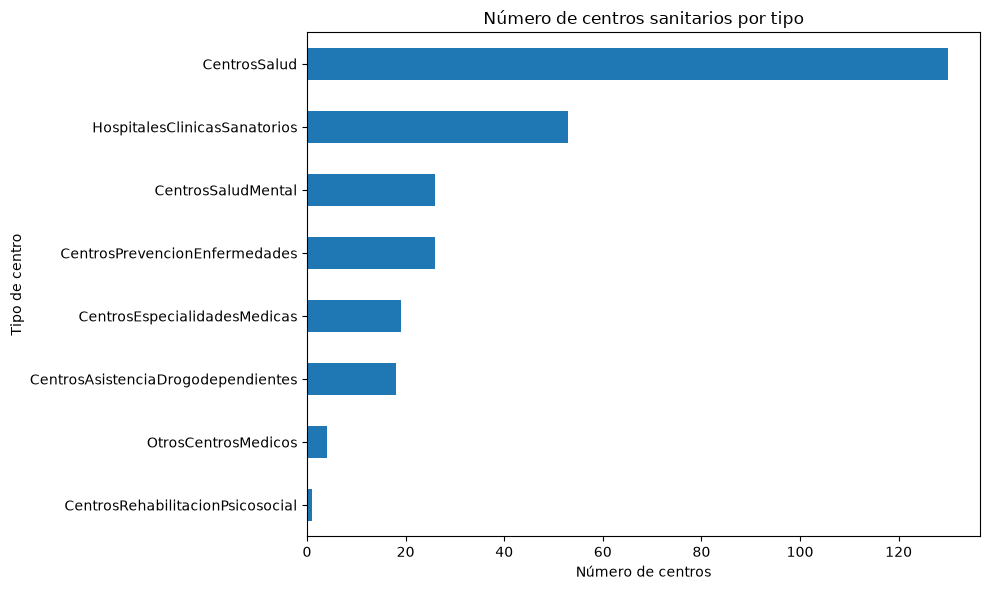

In [16]:
# Gráfico de centros sanitarios por tipo

df_clean["TIPO_LIMPIO"].value_counts().sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Número de centros sanitarios por tipo")
plt.xlabel("Número de centros")
plt.ylabel("Tipo de centro")
plt.tight_layout()
plt.show()

15 barrios con mayor número de centros:
BARRIO
LISTA                   7
CIUDAD UNIVERSITARIA    7
PUERTA DEL ANGEL        6
SAN DIEGO               6
BUENAVISTA              6
LA PAZ                  6
ARGUELLES               5
PALOMERAS SURESTE       5
RIOS ROSAS              5
IMPERIAL                5
VALLEHERMOSO            5
LAS AGUILAS             5
PROSPERIDAD             4
CANILLAS                4
ALUCHE                  4
Name: count, dtype: int64


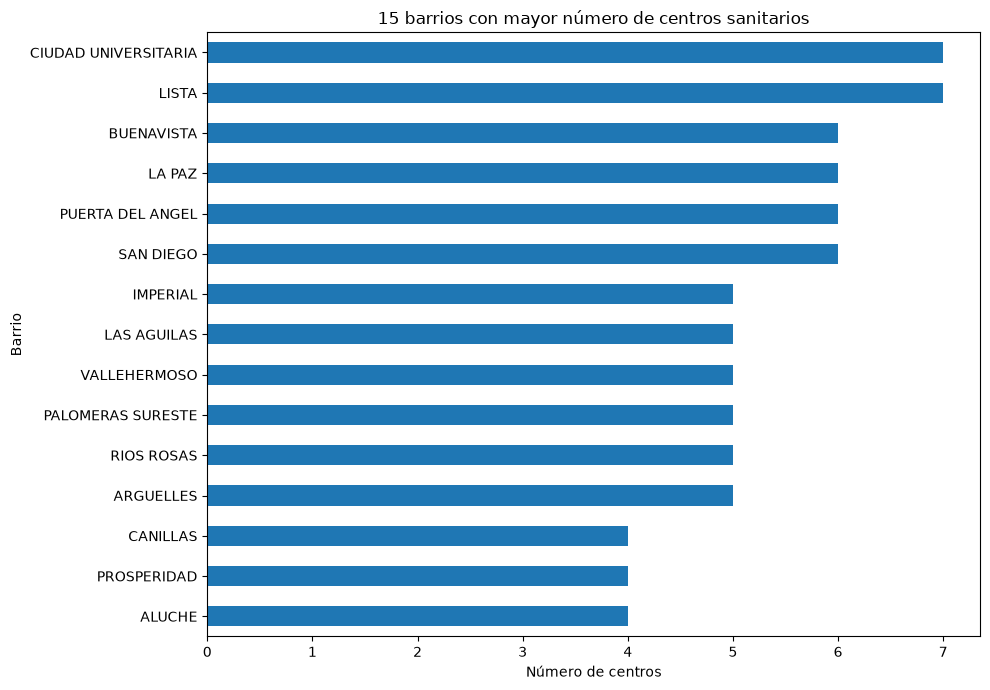

In [17]:
# 6. DISTRIBUCIÓN GEOGRÁFICA DE LOS CENTROS SANITARIOS

# Número de centros por barrio
centros_barrio = (
    df_clean["BARRIO"]
    .value_counts()
    .sort_values(ascending=False)
)

print("15 barrios con mayor número de centros:")
print(centros_barrio.head(15))

# Gráfico de los 15 barrios con mayor número de centros

centros_barrio.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("15 barrios con mayor número de centros sanitarios")
plt.xlabel("Número de centros")
plt.ylabel("Barrio")
plt.tight_layout()
plt.show()

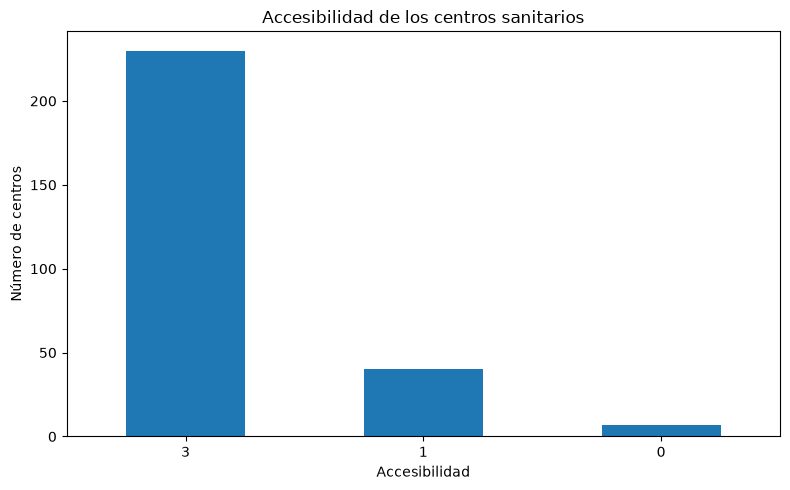

In [18]:
# Gráfico de accesibilidad

df_clean["ACCESIBILIDAD"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Accesibilidad de los centros sanitarios")
plt.xlabel("Accesibilidad")
plt.ylabel("Número de centros")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
# 8.ANALISIS DE LAS CARACTERISTICAS DE LOS CENTROS SANITARIOS 

# Información sobre los horarios
print("Ejemplos de horarios:")
display(df_clean["HORARIO"].dropna().head(10))

print("\nNúmero de centros con información de horario:")
print(df_clean["HORARIO"].notna().sum())

print("\nNúmero de centros sin información de horario:")
print(df_clean["HORARIO"].isna().sum())

# Número de centros con y sin información de horario
centros_con_horario = df_clean["HORARIO"].notna().sum()
centros_sin_horario = df_clean["HORARIO"].isna().sum()

print("Centros con información de horario:", centros_con_horario)
print("Centros sin información de horario:", centros_sin_horario)

# Porcentaje de centros con información de horario
porcentaje_con_horario = (
    centros_con_horario / len(df_clean) * 100
)

print(
    f"Porcentaje de centros con información de horario: "
    f"{porcentaje_con_horario:.2f}%")

Ejemplos de horarios:


0                   De lunes a viernes de 9 a 17 horas
1    De lunes a viernes mañanas de 9 a 14 horas, ta...
2                   De lunes a viernes de 9 a 17 horas
3    Horario ordinario:   De septiembre a junio:   ...
4    Horario ordinario:   De septiembre a junio:   ...
5    Horario ordinario:   De septiembre a junio:   ...
6    Horario ordinario:   De septiembre a junio:   ...
7    Horario ordinario:   De septiembre a junio:   ...
8    Horario ordinario:   De septiembre a junio:   ...
9    Horario ordinario:   De septiembre a junio:   ...
Name: HORARIO, dtype: str


Número de centros con información de horario:
90

Número de centros sin información de horario:
187
Centros con información de horario: 90
Centros sin información de horario: 187
Porcentaje de centros con información de horario: 32.49%


In [20]:

# Información sobre el equipamiento
print("\nEjemplos de equipamiento:")
display(df_clean["EQUIPAMIENTO"].dropna().head(10))

# Número de centros con y sin información de equipamiento
centros_con_equipamiento = df_clean["EQUIPAMIENTO"].notna().sum()
centros_sin_equipamiento = df_clean["EQUIPAMIENTO"].isna().sum()

print(
    "\nNúmero de centros con información de equipamiento:",
    centros_con_equipamiento
)

print(
    "Número de centros sin información de equipamiento:",
    centros_sin_equipamiento
)

# Porcentaje de centros con información de equipamiento
porcentaje_con_equipamiento = (
    centros_con_equipamiento / len(df_clean) * 100
)

print(
    f"Porcentaje de centros con información de equipamiento: "
    f"{porcentaje_con_equipamiento:.2f}%"
)


Ejemplos de equipamiento:


0    Valoración interdisciplinar del/de la paciente...
1    Valoración interdisciplinar del/de la paciente...
2    Valoración interdisciplinar del paciente. Trat...
3    Valoración interdisciplinar de cada usuario.  ...
4    Valoración interdisciplinar de cada usuario.  ...
5    Valoración interdisciplinar de cada usuario.  ...
6    Valoración interdisciplinar de cada usuario.  ...
7    Valoración interdisciplinar de cada usuario.  ...
8    Valoración interdisciplinar de cada usuario.  ...
9    Valoración interdisciplinar de cada usuario.  ...
Name: EQUIPAMIENTO, dtype: str


Número de centros con información de equipamiento: 48
Número de centros sin información de equipamiento: 229
Porcentaje de centros con información de equipamiento: 17.33%


In [21]:

# Información sobre el transporte
print("\nEjemplos de transporte:")
display(df_clean["TRANSPORTE"].dropna().head(10))

# Número de centros con y sin información de transporte
centros_con_transporte = df_clean["TRANSPORTE"].notna().sum()
centros_sin_transporte = df_clean["TRANSPORTE"].isna().sum()

print(
    "\nNúmero de centros con información de transporte:",
    centros_con_transporte
)

print(
    "Número de centros sin información de transporte:",
    centros_sin_transporte
)

# Porcentaje de centros con información de transporte
porcentaje_con_transporte = (
    centros_con_transporte / len(df_clean) * 100
)

print(
    f"Porcentaje de centros con información de transporte: "
    f"{porcentaje_con_transporte:.2f}%"
)


Ejemplos de transporte:


0                  Metro: Alonso Martínez, L4, L5, L10
1    Bus: 9, 73, N2Metro: Alfonso XIII (L4), Prospe...
2    Bus: 31, 33, 36, 39, 65, 138 Metro:Puerta del ...
3    Bus: 6 , 8 , 18 , 19 , 22 , 45 , 47 , 76 , 78 ...
4    Bus: 73, 87, 104, 112, 120, 125, 153, 172Metro...
5    Bus: 25 , 31, 138Metro: Laguna (L 6), Casa de ...
6           Bus: 77, 104, 105, 775Metro: Suances (L 5)
7    Bus: 42Metro: Ventilla (L-9), Valdeacederas (L...
8    Bus: 10, 24, 54, 57, 58, 111, 136, 140, 310Met...
9    Bus: 76Renfe: Cercanías Puente Alcocer Bicicle...
Name: TRANSPORTE, dtype: str


Número de centros con información de transporte: 266
Número de centros sin información de transporte: 11
Porcentaje de centros con información de transporte: 96.03%


In [22]:
# RESUMEN DE LA INFORMACIÓN DISPONIBLE 

resumen_caracteristicas = pd.DataFrame({
    "Variable": ["HORARIO", "EQUIPAMIENTO", "TRANSPORTE"],
    "Con información": [
        df_clean["HORARIO"].notna().sum(),
        df_clean["EQUIPAMIENTO"].notna().sum(),
        df_clean["TRANSPORTE"].notna().sum()
    ],
    "Sin información": [
        df_clean["HORARIO"].isna().sum(),
        df_clean["EQUIPAMIENTO"].isna().sum(),
        df_clean["TRANSPORTE"].isna().sum()
    ],
})

resumen_caracteristicas["% con información"] = (
    resumen_caracteristicas["Con información"]
    / len(df_clean) * 100
).round(2)

display(resumen_caracteristicas)

,Variable,Con información,Sin información,% con información
0,HORARIO,90,187,32.49
1,EQUIPAMIENTO,48,229,17.33
2,TRANSPORTE,266,11,96.03


In [23]:
# 9. RESUMEN GENERAL DEL ANALISIS

print("RESUMEN DEL ANÁLISIS")
print("-" * 40)

print("Número total de centros:", len(df_clean))

print("Número de tipos de centros:", df_clean["TIPO_LIMPIO"].nunique())

print("Número de barrios representados:", df_clean["BARRIO"].nunique())

print(
    "Centros con información de accesibilidad:",
    df_clean["ACCESIBILIDAD"].notna().sum()
)

print(
    "Centros con información de transporte:",
    df_clean["TRANSPORTE"].notna().sum()
)

print("\nTipo de centro más frecuente:")
print(df_clean["TIPO_LIMPIO"].value_counts().head(1))

print("\nBarrio con mayor número de centros:")
print(df_clean["BARRIO"].value_counts().head(1))

RESUMEN DEL ANÁLISIS
----------------------------------------
Número total de centros: 277
Número de tipos de centros: 8
Número de barrios representados: 116
Centros con información de accesibilidad: 277
Centros con información de transporte: 266

Tipo de centro más frecuente:
TIPO_LIMPIO
CentrosSalud    130
Name: count, dtype: int64

Barrio con mayor número de centros:
BARRIO
LISTA    7
Name: count, dtype: int64


### 10. CONCLUSIONES
<p style="text-align: justify;"> El análisis realizado sobre los centros sanitarios de Madrid permite obtener
una visión general de la oferta sanitaria y de su distribución territorial. </p>

<p style="text-align: justify;"> El conjunto de datos contiene 277 centros sanitarios pertenecientes a 8 tipos
diferentes y distribuidos entre 116 barrios. Los Centros de Salud constituyen
la categoría más frecuente, con 130 centros, lo que representa aproximadamente
el 47 % del conjunto analizado. </p>

<p style="text-align: justify;"> Desde el punto de vista territorial, los centros no se distribuyen de manera
uniforme entre los barrios. El barrio de LISTA presenta el mayor número de
centros, con 7 establecimientos. </p>

<p style="text-align: justify;"> En relación con la accesibilidad, todos los centros incluidos en el conjunto
disponen de información en esta variable. Además, la información sobre
transporte presenta una cobertura elevada: 266 de los 277 centros (96,03 %)
disponen de información sobre las opciones de transporte disponibles. </p>

<p style="text-align: justify;"> Sin embargo, el análisis también pone de manifiesto algunas limitaciones en
la calidad de los datos. La información sobre horarios está disponible
únicamente para el 32,49 % de los centros, mientras que la información sobre
equipamiento solo está disponible para el 17,33 %. Por tanto, estas variables
deben interpretarse con cautela y no permiten realizar conclusiones generales
sobre todos los centros. </p>

<p style="text-align: justify;"> En conjunto, el análisis muestra cómo herramientas de Python, Pandas y
Matplotlib permiten transformar un conjunto de datos públicos en información
útil sobre la oferta sanitaria, su distribución territorial y algunas de sus
características. </p>